In [2]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 79.4 MB/s eta 0:00:00


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Dense, Flatten, Reshape, Lambda,
    Concatenate, BatchNormalization, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import backend as K

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [6]:
# 10 nhãn của FashionMNIST
text_labels = [
    't-shirt', 'trouser', 'pullover', 'dress', 'coat',
    'sandal',  'shirt',   'sneaker',  'bag',   'ankle boot'
]

# Tokenize từng nhãn
# 'ankle boot' → ['ankle', 'boot']
tokenized = [word_tokenize(label.lower()) for label in text_labels]

# Train Word2Vec
w2v_model = Word2Vec(
    tokenized,
    vector_size=10,   # Mỗi từ → vector 10 chiều
    window=1,          # Xét từ liền kề (danh sách nhỏ)
    min_count=1,       # Bao gồm mọi từ dù 1 lần
    sg=0              # CBOW (không phải Skip-gram)
)

# Tạo embedding cho mỗi nhãn
# Multi-word label → lấy trung bình các từ
label_embeddings = {}
for label, tokens in zip(text_labels, tokenized):
    vecs = [w2v_model.wv[t] for t in tokens if t in w2v_model.wv]
    label_embeddings[label] = np.mean(vecs, axis=0) if vecs else np.zeros(10)

# Tạo embedding matrix: shape (num_samples, 10)
def get_label_embedding(y_labels, text_labels, label_embeddings):
    embs = []
    for y in y_labels:
        embs.append(label_embeddings[text_labels[y]])
    return np.array(embs, dtype='float32')

In [7]:
# Hyperparameters
latent_dim   = 2   # Latent space 2D để dễ visualize
label_dim    = 10  # Word2Vec embedding size
hidden_dim   = 256

# Hàm lấy mẫu z — Reparameterization Trick
def sampling(args):
    mu, logvar = args
    epsilon = K.random_normal(shape=K.shape(mu))
    return mu + K.exp(0.5 * logvar) * epsilon

# ── ENCODER ──────────────────────────────────────────
img_input   = Input(shape=(28, 28, 1), name='img_input')
label_input = Input(shape=(label_dim,),    name='label_input')

# Xử lý ảnh
x = Flatten()(img_input)               # → 784
x = Dense(hidden_dim, activation='relu')(x)

# Ghép ảnh + label embedding
x = Concatenate()([x, label_input])    # → 256 + 10 = 266
x = Dense(hidden_dim, activation='relu')(x)

# 2 nhánh output: μ và logvar
z_mean   = Dense(latent_dim, name='z_mean')(x)
z_logvar = Dense(latent_dim, name='z_logvar')(x)

# Lấy mẫu z với Reparameterization
z = Lambda(sampling, name='z')([z_mean, z_logvar])

encoder = Model(
    [img_input, label_input],
    [z_mean, z_logvar, z],
    name='vae_encoder'
)

In [8]:
# ── DECODER ──────────────────────────────────────────
z_input     = Input(shape=(latent_dim,), name='z_input')
label_input2 = Input(shape=(label_dim,), name='label_input_dec')

# Ghép z + label để điều kiện hóa generation
x = Concatenate()([z_input, label_input2])  # → 2 + 10 = 12
x = Dense(hidden_dim, activation='relu')(x)
x = Dense(784,        activation='sigmoid')(x)  # → 784, output [0,1]
x = Reshape((28, 28, 1))(x)                   # → 28×28×1

decoder = Model(
    [z_input, label_input2],
    x,
    name='vae_decoder'
)

In [14]:
# ── MODEL ─────────────────────────────────────────────
# Define a custom layer to compute and add the VAE loss
class VAELossLayer(tf.keras.layers.Layer):
    def call(self, inputs):
        img_in, x_recon, z_mean, z_logvar = inputs

        x_flat = Flatten()(img_in)
        recon_flat = Flatten()(x_recon)
        recon_loss = tf.keras.ops.mean(
            tf.keras.ops.binary_crossentropy(x_flat, recon_flat)
        ) * 784

        kl_loss = -0.5 * tf.keras.ops.mean(
            1 + z_logvar - tf.keras.ops.square(z_mean) - tf.keras.ops.exp(z_logvar)
        )
        total_vae_loss = recon_loss + kl_loss
        self.add_loss(total_vae_loss) # This is allowed within a Layer's call method
        return x_recon # Return x_recon unchanged, as this layer's primary purpose is to add loss

# ── MODEL ─────────────────────────────────────────────
img_in   = Input(shape=(28, 28, 1))
label_in = Input(shape=(label_dim,))

z_mean, z_logvar, z = encoder([img_in, label_in])
x_recon = decoder([z, label_in])

# Create an instance of the VAELossLayer and pass the necessary tensors
x_recon_with_loss = VAELossLayer()([img_in, x_recon, z_mean, z_logvar])

# The VAE model now outputs x_recon_with_loss which is just x_recon,
# but the VAELossLayer has added the loss to the model's internal losses list.
vae = Model([img_in, label_in], x_recon_with_loss, name='vae')

# Compile the model without an explicit loss, as it's added internally
vae.compile(optimizer='adam')

In [15]:
# Tải FashionMNIST
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0
x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test,  -1)

# Tạo label embeddings cho toàn bộ dataset
train_embs = get_label_embedding(y_train, text_labels, label_embeddings)
test_embs  = get_label_embedding(y_test,  text_labels, label_embeddings)

# Huấn luyện
history = vae.fit(
    [x_train, train_embs], x_train,
    epochs=50,
    batch_size=128,
    validation_data=([x_test, test_embs], x_test)
)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 300.2734 - val_loss: 275.1479
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 268.3620 - val_loss: 265.8960
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 262.4066 - val_loss: 262.2973
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 259.5301 - val_loss: 259.8695
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 257.6163 - val_loss: 258.4883
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 256.3141 - val_loss: 257.5148
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 255.3415 - val_loss: 256.5554
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 254.5807 - val_loss: 256.2791
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 254.0377 - val_loss: 255.8374
E

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


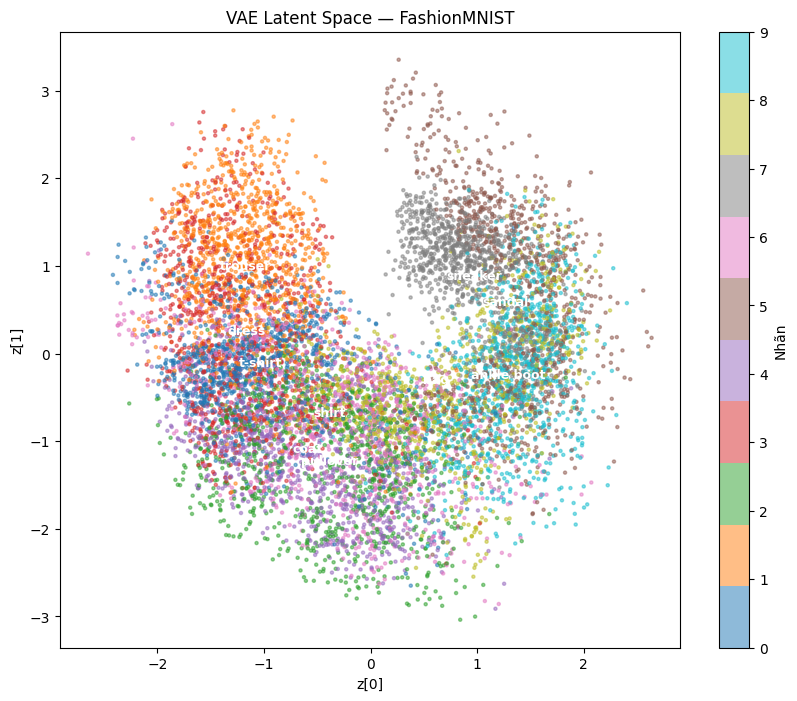

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


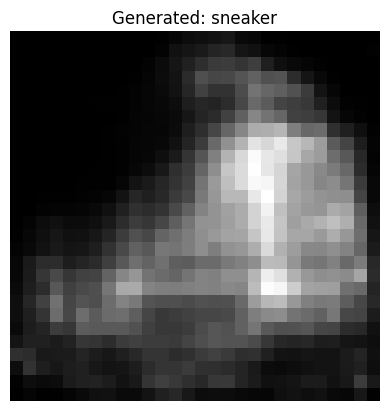

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


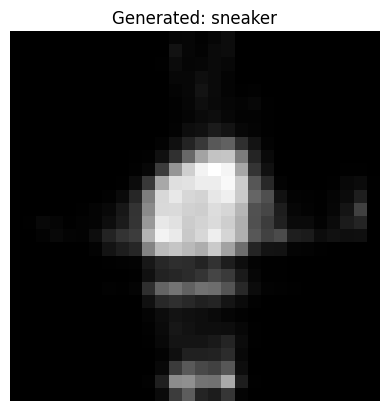

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


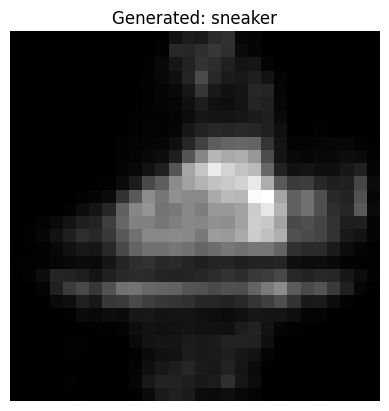

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


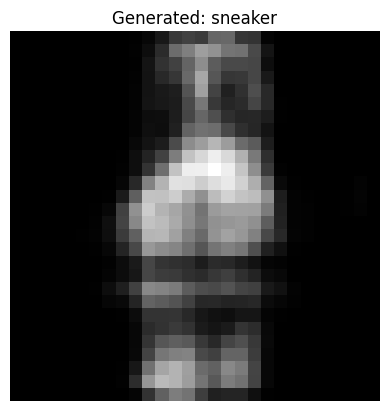

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


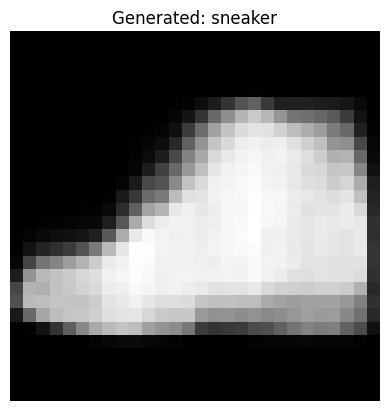

In [16]:
# Encode toàn bộ test set vào latent space 2D
z_mean_test, _, _ = encoder.predict([x_test, test_embs])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    z_mean_test[:, 0], z_mean_test[:, 1],
    c=y_test, cmap='tab10', alpha=0.5, s=5
)
plt.colorbar(scatter, label='Nhãn')
plt.title('VAE Latent Space — FashionMNIST')
plt.xlabel('z[0]'); plt.ylabel('z[1]')

# Thêm tên nhãn vào từng cụm
for i, label in enumerate(text_labels):
    mask = y_test == i
    cx = z_mean_test[mask, 0].mean()
    cy = z_mean_test[mask, 1].mean()
    plt.annotate(label, (cx, cy), fontsize=9, ha='center',
                 color='white', fontweight='bold')
plt.show()

# ── Generate ảnh mới theo nhãn ───────────────────────
def generate_by_label(label_name, n=5):
    emb = label_embeddings[label_name]
    for _ in range(n):
        z_sample = np.random.normal(0, 1, (1, latent_dim))
        label_emb = emb.reshape(1, -1)
        img = decoder.predict([z_sample, label_emb])
        plt.imshow(img[0].squeeze(), cmap='gray')
        plt.title(f'Generated: {label_name}')
        plt.axis('off'); plt.show()

generate_by_label('sneaker')